In [1]:
from torchvision.datasets import ImageFolder
import torch
import numpy as np

if torch.cuda.is_available():
    device = "cuda"
elif torch.mps.is_available():
    device = "mps"
else:
    device = "cpu"

torch.manual_seed(42)
np.random.seed(42)


data_root_folder = "data"

full_dataset = ImageFolder(root=data_root_folder)

In [2]:
from collections import Counter

n_samples = 1000

class_labels = full_dataset.targets

class_counts = Counter(class_labels)

class_proportions = {
    label: count / len(class_labels) for label, count in class_counts.items()
}

target_counts = {
    label: int(np.ceil(p * n_samples)) for label, p in class_proportions.items()
}

test_labels = []
for class_idx, count in target_counts.items():
    test_labels.extend([class_idx] * count)

np.random.shuffle(test_labels)
test_labels = test_labels[:1000]

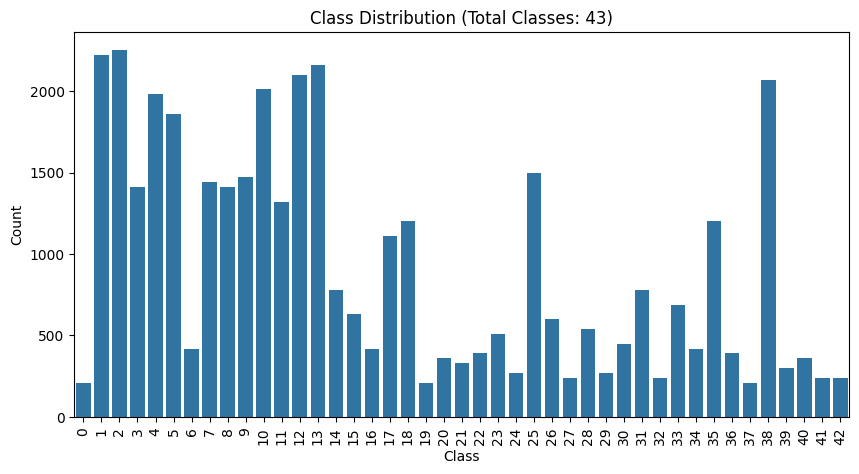

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns


def plot_class_distribution(class_counts, n_classes):
    plt.figure(figsize=(10, 5))
    sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()))
    plt.xlabel("Class")
    plt.ylabel("Count")
    plt.title(f"Class Distribution (Total Classes: {n_classes})")
    plt.xticks(rotation=90)
    plt.show()


plot_class_distribution(class_counts, len(class_counts))

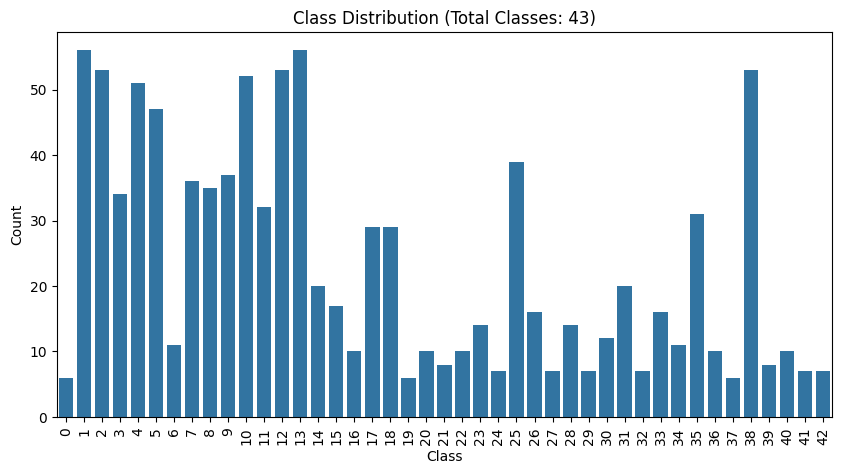

In [4]:
test_class_counts = Counter(test_labels)
plot_class_distribution(test_class_counts, len(test_class_counts))

In [5]:
from model import ConditionalDCGAN

ckpt_path = "trafic-signs-generation/a6hgd27y/checkpoints/model-epoch=99.ckpt"

model = ConditionalDCGAN.load_from_checkpoint(ckpt_path).to("mps")

In [6]:
latent_dim = 128

noise = torch.randn(
    n_samples,
    latent_dim,
    device=device,
)
labels = torch.tensor(test_labels, device=device)

model.eval()

with torch.inference_mode():
    generated_images = model(noise, labels)

torch.save(generated_images.cpu().detach(), "piatek_Machniak_Tokajuk.pt")


In [7]:
import os
import shutil
from torchvision.utils import save_image


output_images_dir = "generated_images"

if os.path.exists(output_images_dir):
    shutil.rmtree(output_images_dir)
os.makedirs(output_images_dir, exist_ok=True)

for i in range(generated_images.size(0)):
    img_tensor = generated_images[i].squeeze()

    label_index = labels[i]

    class_name = full_dataset.classes[label_index]

    filename = f"{class_name}_{i:04d}.jpg"
    filepath = os.path.join(output_images_dir, filename)

    img_to_save = (img_tensor + 1) / 2.0
    save_image(img_to_save, filepath)


In [8]:
test_images_dir = "test_images"

if not os.path.exists(test_images_dir):
    os.makedirs(test_images_dir)

    for class_name in os.listdir(data_root_folder):
        class_dir_path = os.path.join(data_root_folder, class_name)
        for filename in os.listdir(class_dir_path):
            src_file_path = os.path.join(class_dir_path, filename)
            dst_file_path = os.path.join(test_images_dir, f"{class_name}_{filename}")
            shutil.copyfile(src_file_path, dst_file_path)


In [9]:
from pytorch_fid.fid_score import calculate_fid_given_paths

calculate_fid_given_paths(
    [output_images_dir, test_images_dir], batch_size=128, device=device, dims=2048
)

100%|██████████| 307/307 [09:10<00:00,  1.79s/it]


np.float64(73.42995659405454)